# Lecture 7 — Krusell-Smith and CVIAYN

**Computational Methods for Heterogeneous-Agent Macro**

Jeffrey Sun

## 1. Setup

In [1]:
using Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

using HouseholdStages
using Flux
using Flux: Chain, Dense, swish, Adam, withgradient
using Printf
using Statistics
using LinearAlgebra
using Random: MersenneTwister, seed!
using Plots

  Activating project at `~/projects/research/CV is all you need`


## 2. The Krusell-Smith setup

The **Krusell-Smith** model is Aiyagari with an **aggregate** Markov process for TFP $A$.

This means that the ``perfect-foresight'' method we used for the MIT shock will no longer work.

With stochastic aggregate productivity $Z_t$, prices $r_t, w_t$ depend on $(Z_t, K_t)$. Now, if the household could anticipate $K_{t+1}$ from $K_t$ alone, then we could treat $K_t$ much like just another idiosyncratic state variable. (This is basically the trick used by so-called ``block-recursive'' models.)

But sadly, no such luck here: In this case, $K_{t+1}$ is the integral of *all* households' savings choices, which (due to heterogeneity) depend on the entire wealth distribution $\Lambda_t$.

So the agent's own state space has to include $\Lambda_t$ to make truly rational (i.e. rational-expectations) decisions:
$$V(b, z; \Lambda, Z) = \max_{c, b'} u(c) + \beta\, \mathbb{E}[V(b', z'; \Lambda', Z') \mid z, Z].$$

But a grid over **all possible values** of $\Lambda_t$ is infeasible. We need some kind of dimension reduction.

Here, we cover two such methods. The latter is my own contribution:

- **§3 — Krusell-Smith (1998):** assume agents track only the first moment $K_t$ and forecast $K_{t+1}$ from a parametric log-linear rule. Solve the implied 4D VFI, simulate, refit the rule. Approximate aggregation makes this work.
- **§4 — CVIAYN:** parameterise $V_\theta(b, z, \Lambda, Z)$ directly with a neural network that conditions on the full distribution $\Lambda$ via a learned generalized moment. Drop the ALM, drop the regression, train against the outer Bellman residual.

This notebook and the next demonstrate two methods solving the same **Krusell-Smith** model.

We start by building that model.

### 2.1 Parameters

In [2]:
@kwdef struct KSParams
    β::Float64 = 0.96
    γ::Float64 = 1.0
    α::Float64 = 0.36
    δ::Float64 = 0.025
    # Idiosyncratic productivity z (unemployed / employed)
    z_grid::Vector{Float64} = [0.07, 1.0]
    Π_z::Matrix{Float64}    = [0.6   0.4;
                               0.05  0.95]
    # Aggregate TFP Z (bad / good)
    Z_vals::Vector{Float64} = [0.99, 1.01]
    Π_Z::Matrix{Float64}    = [0.875 0.125;
                               0.125 0.875]
    # Wealth grid
    N_b::Int       = 80
    b_min::Float64 = 0.0
    b_max::Float64 = 80.0
    # K grid (for the K-S 4D VFI; not used by CVIAYN)
    N_K::Int       = 5
    K_min::Float64 = 10.5
    K_max::Float64 = 14.5
end

KSParams

### 2.2 Prices and effective labour

Cobb-Douglas production with TFP $Z$ and effective labour $L$:
$$R(Z, K) = \alpha\, Z\, (K/L)^{\alpha-1} + 1 - \delta, \qquad w(Z, K) = (1-\alpha)\, Z\, (K/L)^\alpha.$$

Effective labour is the stationary-distribution average of $z$. It is constant in this model since $\Pi_z$ is independent of $Z$.

In [3]:
function markov_stationary_mean(Π_z::AbstractMatrix, z_grid::AbstractVector)
    v = real.(eigvecs(Π_z')[:, end])
    return z_grid ⋅ (v ./ sum(v))
end

function ks_prices(K, Z, p::KSParams)
    L = markov_stationary_mean(p.Π_z, p.z_grid)
    R = p.α * Z * (K/L)^(p.α - 1) + 1 - p.δ
    w = (1 - p.α) * Z * (K/L)^p.α
    return (; R, w)
end

ks_prices (generic function with 1 method)

### 2.3 The inner household chain (3 stages)

The within-period block is the same as Aiyagari: `z_shock ∘ income ∘ savings`.

In [4]:
_u_crra(c, ::Val{1}) = log(c)
_u_crra(c, ::Val{1.0}) = log(c)
_u_crra(c, ::Val{σ}) where σ = (c^(1 - σ)) / (1 - σ)
u_crra(c, valσ::Val) = c < 0 ? -Inf : _u_crra(c, valσ)

"Three-stage household chain: z_shock ∘ income ∘ savings. Prices are read from env."
function ks_household(p::KSParams)
    # Define layout: axis 1 (wealth) is continuous, axis 2 (z) is discrete.
    layout = StateLayout(
        StateAxis(:wealth, continuous_grid(p.b_min, p.b_max; length=p.N_b, spacing=:log)),
        StateAxis(:z, p.z_grid),
    )

    # Define the three stages.
    z_shock = MarkovStage(layout; axis=:z, transition=p.Π_z)
    income  = WealthChangeStage(layout; wealth_post=(cell; env) -> env.R * cell.wealth + env.w * cell.z)
    savings = ConsumptionSavingsStage(layout; β=p.β, utility=(cell, c; env) -> u_crra(c, Val(p.γ)), monotone_search=:divide_conquer)

    # Build the household chain and define a moment.
    hh = z_shock ∘ income ∘ savings
    return define_moments!(hh; K_supplied=at_end(integrand=:wealth, reduce=sum))
end

ks_household

### 2.4 Deterministic Aiyagari SS at $Z = 1$

Before adding aggregate uncertainty, find the deterministic steady state $\bar K$ at $Z = 1$ using tatonnement.

In [5]:
"Solve the deterministic Aiyagari steady state at given Z via damped tatonnement on K."
function aiyagari_steady_state_at_Z(p::KSParams; Z=1.0, K_init=12.0, update_speed=0.05, rtol=1e-2, maxiter=200, verbosity=0)
    local V, Λ
    hh = ks_household(p)
    K  = K_init
    V, Λ = nothing, nothing

    err = Inf
    iters = 0
    while err >= rtol
        env = make_env(hh; ks_prices(K, Z, p)...)
        (;V, Λ, moments) = solve_steady_state_given_env!(hh, env; V_init=V, Λ_init=Λ, lambda_tol=1e-5, lambda_maxiter=50_000)
        K_supplied = moments.K_supplied
        err = abs(K_supplied - K) / K
        K = (1 - update_speed)*K + update_speed*K_supplied

        verbosity >= 1 && @printf "  iter %d: K = %.4f → K_supplied = %.4f, err = %.2e\n" iters K K_supplied err
        iters = iters + 1
        iters > maxiter && error("aiyagari_steady_state_at_Z did not converge in $maxiter iterations")
    end

    return (; K, V, Λ, iters)
end

aiyagari_steady_state_at_Z

## 3. Solving via Krusell-Smith regression

**Krusell-Smith (1998).** Make a **bounded-rationality assumption**: agents do not track the entire distribution $\Lambda_t$. They track only its first moment $K_t$ and forecast next period's $K$ from $(K_t, Z_t)$ via a **parametric Approximate Law of Motion** (ALM):
$$\log K_{t+1} = a_0(Z_t) + a_1(Z_t) \log K_t.$$

Given $(a_0, a_1)$, the household's state collapses to $(b, z, Z, K)$. This is low-dimensional and solvable by VFI. It simply requires us to build a slightly longer household chain that includes the $K$ and $Z$, effectively as idiosyncratic state variables.

We set $(a_0, a_1)$ by indirect inference--OLS on simulated data. We must iterate on this as updating $(a_0, a_1)$ changes behaviour, which changes aggregate dynamics:

1. **Pick** an initial ALM $(a_0^{(0)}, a_1^{(0)})$.
2. **Solve** the 4D household problem at the current ALM: get $V^*$ and policy.
3. **Simulate** the *true* (non-ALM) economy for many periods with $\{Z_t\}$ drawn stochastically and *true* aggregation $K_t = \int b\, \mathrm{d}\Lambda_t$.
4. **Refit** $(a_0, a_1)$ by OLS of $\log K_{t+1}$ on $\log K_t$, separately per $Z$ state.
5. **Iterate** until $(a_0, a_1)$ stops moving.

### 3.1 The 5-stage behavioural household block (with K_evolve, Z_shock)

For the K-S VFI we extend the 3-stage chain to 5 stages by appending the **agent's belief** about $K, Z$ dynamics at the end:

1. **`z_shock`** — idiosyncratic productivity $z_t \to z_{t+1}$ (Markov on `:z`).
2. **`income`** — wealth update with $R, w$ at the cell's current $(Z, K)$.
3. **`savings`** — choose $b_{t+1}$ on the wealth grid.
4. **`K_evolve`** — deterministic $K_t \to K_{t+1}$ under the ALM. Linear interpolation on the K-grid.
5. **`Z_shock`** — $Z_t \to Z_{t+1}$ (Markov on `:Z_idx`).

In [6]:
"""
Five-stage K-S behavioural household block:
3-stage inner chain plus K_evolve and Z_shock under the agent's ALM.
"""
function behavioural_alm_household(p::KSParams)
    # Define layout, adding a Z_idx axis and a K axis.
    layout = StateLayout(
        StateAxis(:wealth, continuous_grid(p.b_min, p.b_max; length=p.N_b, spacing=:log)),
        StateAxis(:z,      p.z_grid),
        StateAxis(:Z_idx,  [1, 2]),
        StateAxis(:K,      continuous_grid(p.K_min, p.K_max; length=p.N_K)),
    )

    # The original three stages
    z_shock = MarkovStage(layout; axis=:z, transition=p.Π_z)
    income  = WealthChangeStage(layout; wealth_post=(cell; env) -> begin
        Z = p.Z_vals[cell.Z_idx]
        (;R, w) = ks_prices(cell.K, Z, p)
        R * cell.wealth + w * cell.z
    end)
    savings = ConsumptionSavingsStage(layout; β=p.β, utility=(cell, c; env) -> u_crra(c, Val(p.γ)), monotone_search=:divide_conquer)
    # Stage 4: Approximate law of motion for K
    K_evolve = WealthChangeStage(layout; wealth_axis=:K, wealth_post=(cell; env) -> exp(env.a0[cell.Z_idx] + env.a1[cell.Z_idx] * log(cell.K)))
    # Stage 5: ``Aggregate'' TFP shock
    Z_shock = MarkovStage(layout; axis=:Z_idx, transition=p.Π_Z)

    chain = z_shock ∘ income ∘ savings ∘ K_evolve ∘ Z_shock
    return define_moments!(chain; K_supplied=at_end(integrand=:wealth, reduce=sum))
end

behavioural_alm_household

### 3.3 Simulation under realised $(Z_t, K_t)$

To simulate the *true* model, restrict the household distribution $\Lambda_t$ to $(b, z)$, and simulate $(Z_t, K_t)$ properly.

In [7]:
"Linear-interpolation weights between the two K-grid points bracketing K_t."
function K_neighbours(K_grid::AbstractVector, K_t)
    K_c = clamp(K_t, K_grid[1], K_grid[end])
    i_hi = findfirst(>=(K_c), K_grid)
    i_hi == 1 && return (1, 1, 1.0)
    i_lo = i_hi - 1
    w_lo = (K_grid[i_hi] - K_c) / (K_grid[i_hi] - K_grid[i_lo])
    return (i_lo, i_hi, w_lo)
end

"Simulate Λ_2d forward one period through the 5-stage `hh_4d`."
function ks_simulate_step(hh_4d, p::KSParams, Λ_2d::AbstractMatrix, Z_idx::Int, K_t)
    K_grid = axisvalues(input_layout(hh_4d).axes[4])
    i_lo, i_hi, w_lo = K_neighbours(K_grid, K_t)
    N_b, N_z = size(Λ_2d)
    N_Z, N_K = length(p.Z_vals), length(K_grid)

    # Lift Λ_2d to the 4D state space the households' beliefs operate in, redistributing K_t between i_lo and i_hi.
    Λ_4d = zeros(N_b, N_z, N_Z, N_K)
    for j in 1:N_z, i in 1:N_b
        m = Λ_2d[i, j]
        iszero(m) && continue
        Λ_4d[i, j, Z_idx, i_lo] += m * w_lo
        i_lo != i_hi && (Λ_4d[i, j, Z_idx, i_hi] += m * (1 - w_lo))
    end

    # Simulate forward through the 5-stage chain hh_4d
    Λ_4d_next = forward!(hh_4d, Λ_4d)

    # Sum across the Z and K dimensions to recover the new Λ_2d on (b, z).
    return dropdims(sum(Λ_4d_next; dims=(3, 4)); dims=(3, 4))
end

ks_simulate_step

In [8]:
"Sample Z_{t+1} | Z_t from the aggregate Markov chain."
function sample_Z(Z_idx, Π_Z, rng)
    u = rand(rng)
    s = 0.0
    for j in eachindex(view(Π_Z, Z_idx, :))
        s += Π_Z[Z_idx, j]
        u <= s && return j
    end
    return size(Π_Z, 2)
end

"Simulate T periods of (K_t, Z_t) using hh_4d."
function ks_simulate(hh_4d, p::KSParams; T=2000, Λ_init, Z_init=1, rng=MersenneTwister(42))
    b_grid = axisvalues(input_layout(hh_4d).axes[1])
    Λ = copy(Λ_init)
    Z_idx = Z_init
    K_path     = zeros(T)
    Z_idx_path = zeros(Int, T)
    for t in 1:T
        K_t = sum(b_grid .* sum(Λ; dims=2))
        K_path[t]     = K_t
        Z_idx_path[t] = Z_idx
        Λ = ks_simulate_step(hh_4d, p, Λ, Z_idx, K_t)
        Z_idx = sample_Z(Z_idx, p.Π_Z, rng)
    end
    return (; K_path, Z_idx_path)
end

ks_simulate

##### Example: VFI at a constant ALM, then use it to simulate true model

Note that, to solve the behavioural value function, we do not stochastically draw the $Z_t$ shocks. Instead, we simply integrate over $Z$ in the global value function each step.

In [9]:
# Get parameters
p = KSParams()

# Solve deterministic Aiyagari SS at Z = 1.0 to get initial K̄ and Λ_2d.
ss = aiyagari_steady_state_at_Z(p; verbosity=1)
K_bar, Λ_ss, V_ss = ss.K, ss.Λ, ss.V

# Construct the behavioural household and its environment `env`
hh_4d = behavioural_alm_household(p)
a0_init = [log(K_bar), log(K_bar)]
a1_init = [0.0, 0.0]
env0 = make_env(hh_4d; a0=a0_init, a1=a1_init)

# Solve the 4D household behavioural value function by VFI
res4d = solve_steady_state_given_env!(hh_4d, env0; lambda_tol=1e-5, lambda_maxiter=50_000)
T_sim, T_burn = 2000, 500

# Simulate the true model using the initial (constant) behavioural ALM
sim0 = ks_simulate(hh_4d, p; T=T_sim, Λ_init=Λ_ss, Z_init=1)

  iter 0: K = 12.8410 → K_supplied = 28.8200, err = 1.40e+00
  iter 1: K = 13.2660 → K_supplied = 21.3415, err = 6.62e-01
  iter 2: K = 13.6605 → K_supplied = 21.1557, err = 5.95e-01
  iter 3: K = 13.9688 → K_supplied = 19.8263, err = 4.51e-01
  iter 4: K = 14.1889 → K_supplied = 18.3699, err = 3.15e-01
  iter 5: K = 14.1109 → K_supplied = 12.6291, err = 1.10e-01
  iter 6: K = 14.0343 → K_supplied = 12.5794, err = 1.09e-01
  iter 7: K = 13.9595 → K_supplied = 12.5381, err = 1.07e-01
  iter 8: K = 13.8905 → K_supplied = 12.5798, err = 9.88e-02
  iter 9: K = 13.8240 → K_supplied = 12.5605, err = 9.57e-02
  iter 10: K = 13.7597 → K_supplied = 12.5375, err = 9.31e-02
  iter 11: K = 13.7462 → K_supplied = 13.4895, err = 1.96e-02
  iter 12: K = 13.7318 → K_supplied = 13.4593, err = 2.09e-02
  iter 13: K = 13.7161 → K_supplied = 13.4173, err = 2.29e-02
  iter 14: K = 13.6994 → K_supplied = 13.3820, err = 2.44e-02
  iter 15: K = 13.6955 → K_supplied = 13.6206, err = 5.75e-03


(K_path = [13.620593691939678, 13.599807378339015, 13.578890596731316, 13.557886825480956, 13.53685511814634, 13.51588021265539, 13.494940160035632, 13.474090588583229, 13.453416061466449, 13.432946789283648  …  12.955545515952931, 12.963437528410548, 12.955571513197626, 12.9467636137862, 12.93655264660752, 12.925364890769458, 12.913809356543155, 12.902052553217217, 12.890065173573182, 12.877919100600892], Z_idx_path = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  2, 1, 1, 1, 1, 1, 1, 1, 1, 1])

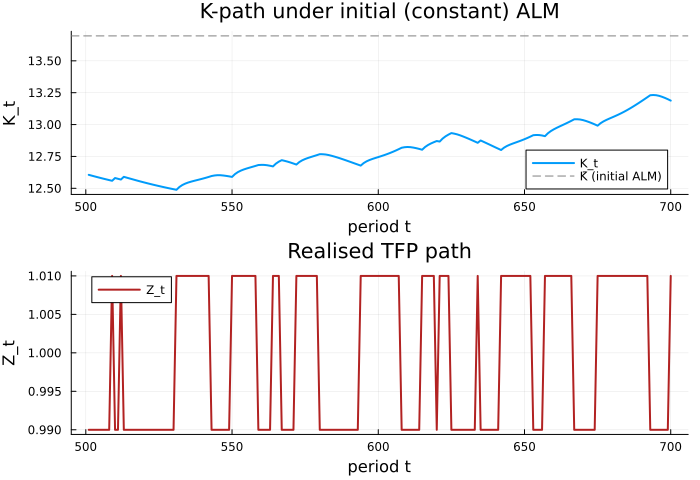

In [10]:
window = (T_burn + 1):(T_burn + 200)
plt_K = plot(window, sim0.K_path[window]; lw=2, label="K_t",
             xlabel="period t", ylabel="K_t",
             title="K-path under initial (constant) ALM", size=(700, 320))
hline!(plt_K, [K_bar]; color=:gray, ls=:dash, label="K̄ (initial ALM)")

plt_Z = plot(window, [p.Z_vals[sim0.Z_idx_path[t]] for t in window];
             lw=2, color=:firebrick, label="Z_t",
             xlabel="period t", ylabel="Z_t",
             title="Realised TFP path", size=(700, 160))

plot(plt_K, plt_Z; layout=(2, 1), size=(700, 480))

### 3.4 Refit the ALM by OLS

Regress $\log K_{t+1}$ on $\log K_t$ **separately by $Z_t$**. The OLS coefficients are the updated $(a_0(Z), a_1(Z))$.

In [11]:
"OLS of log K_{t+1} on (1, log K_t), restricted to periods with Z_t == z_idx and t in window."
function regress_ALM(K_path, Z_idx_path, z_idx, window)
    rows = [t for t in window if Z_idx_path[t] == z_idx]
    x = log.(K_path[rows])
    y = log.(K_path[rows .+ 1])
    x̄, ȳ = mean(x), mean(y)
    Sxx = sum((x .- x̄).^2)
    Sxy = sum((x .- x̄) .* (y .- ȳ))
    a1 = Sxy / Sxx
    a0 = ȳ - a1 * x̄
    ŷ  = a0 .+ a1 .* x
    R² = 1 - sum((y .- ŷ).^2) / sum((y .- ȳ).^2)
    return (; a0, a1, R², n=length(rows))
end

window_fit = (T_burn + 1):(T_sim - 1)
fit_bad  = regress_ALM(sim0.K_path, sim0.Z_idx_path, 1, window_fit)
fit_good = regress_ALM(sim0.K_path, sim0.Z_idx_path, 2, window_fit)
@printf "Z = bad  (Z=%.2f): a0 = %+.4f, a1 = %+.4f, R² = %.4f  (n = %d)\n" p.Z_vals[1] fit_bad.a0 fit_bad.a1 fit_bad.R² fit_bad.n
@printf "Z = good (Z=%.2f): a0 = %+.4f, a1 = %+.4f, R² = %.4f  (n = %d)\n" p.Z_vals[2] fit_good.a0 fit_good.a1 fit_good.R² fit_good.n

Z = bad  (Z=0.99): a0 = +0.0229, a1 = +0.9907, R² = 0.9998  (n = 772)
Z = good (Z=1.01): a0 = -0.0006, a1 = +1.0006, R² = 0.9999  (n = 727)


### 3.5 The K-S outer iteration

Do all of the above (guess $(a_0, a_1)$, simulate using $(a_0,a_1)$, refit $(a_0, a_1)$) until convergence.

In [12]:
"Damped Krusell-Smith outer iteration on the ALM coefficients."
function ks_iterate(p::KSParams, K_bar, Λ_0; update_speed=0.5, rtol=1e-3, maxiter=20, T_sim=2000, T_burn=500, verbosity=0)
    hh_4d = behavioural_alm_household(p)
    a0 = [log(K_bar), log(K_bar)]
    a1 = [0.0, 0.0]
    local sim, fit_bad, fit_good

    err = Inf
    iters = 0
    while err >= rtol
        # Solve 4D VFI at current ALM, then re-seat the simulation chain.
        env = make_env(hh_4d; a0, a1)
        solve_steady_state_given_env!(hh_4d, env; lambda_tol=1e-5, lambda_maxiter=50_000)

        # Simulate under the resulting policy.
        sim = ks_simulate(hh_4d, p; T=T_sim, Λ_init=Λ_0, Z_init=1)
        window_fit = (T_burn + 1):(T_sim - 1)
        fit_bad  = regress_ALM(sim.K_path, sim.Z_idx_path, 1, window_fit)
        fit_good = regress_ALM(sim.K_path, sim.Z_idx_path, 2, window_fit)

        # Extract new ALM coefficients and calculate change
        a0_new = [fit_bad.a0, fit_good.a0]
        a1_new = [fit_bad.a1, fit_good.a1]
        err = maximum(abs.(vcat(a0_new .- a0, a1_new .- a1)))

        # Update coefficients
        a0 = (1 - update_speed) .* a0 .+ update_speed .* a0_new
        a1 = (1 - update_speed) .* a1 .+ update_speed .* a1_new

        # Housekeeping
        verbosity >= 1 && @printf "  iter %d: R² = (%.5f, %.5f), Δ = %.2e, K mean = %.3f\n" iters fit_bad.R² fit_good.R² err mean(sim.K_path[window_fit])
        iters = iters + 1
        iters > maxiter && error("ks_iterate did not converge in $maxiter iterations")
    end

    return (; a0, a1, sim, fit_bad, fit_good, iters)
end

ks_iterate

### 3.6 One Measure of Fit — $R^2 > 0.996$

The converged ALM regression has $R^2$ close to one. The household-block dynamics implied by the converged policy are quite well-described by a one-line log-linear rule.

It appears to be that, in this baseline calibration, the wealth distribution barely matters for the dynamics of $K$. The mean $\bar{K}$ is almost a sufficient statistic: agents who only know $K_t$ and $Z_t$ can forecast $K_{t+1}$ as well as agents who knew the entire $\Lambda_t$.

In [14]:
p = KSParams()
ss = aiyagari_steady_state_at_Z(p; verbosity=1)
K_bar, Λ_ss, V_ss = ss.K, ss.Λ, ss.V

println("Running K-S outer iteration...")
@time res_ks = ks_iterate(p, K_bar, Λ_ss; verbosity=1)
@printf "\nConverged in %d outer iterations.\n" res_ks.iters

@printf "Converged ALM coefficients:\n"
@printf "  Z = bad  (Z=%.2f): log K_{t+1} = %+.4f + %+.4f log K_t\n" p.Z_vals[1] res_ks.a0[1] res_ks.a1[1]
@printf "  Z = good (Z=%.2f): log K_{t+1} = %+.4f + %+.4f log K_t\n" p.Z_vals[2] res_ks.a0[2] res_ks.a1[2]
@printf "Final R²: (bad: %.5f, good: %.5f)\n" res_ks.fit_bad.R² res_ks.fit_good.R²

  iter 0: K = 12.8410 → K_supplied = 28.8200, err = 1.40e+00
  iter 1: K = 13.2660 → K_supplied = 21.3415, err = 6.62e-01
  iter 2: K = 13.6605 → K_supplied = 21.1557, err = 5.95e-01
  iter 3: K = 13.9688 → K_supplied = 19.8263, err = 4.51e-01
  iter 4: K = 14.1889 → K_supplied = 18.3699, err = 3.15e-01
  iter 5: K = 14.1109 → K_supplied = 12.6291, err = 1.10e-01
  iter 6: K = 14.0343 → K_supplied = 12.5794, err = 1.09e-01
  iter 7: K = 13.9595 → K_supplied = 12.5381, err = 1.07e-01
  iter 8: K = 13.8905 → K_supplied = 12.5798, err = 9.88e-02
  iter 9: K = 13.8240 → K_supplied = 12.5605, err = 9.57e-02
  iter 10: K = 13.7597 → K_supplied = 12.5375, err = 9.31e-02
  iter 11: K = 13.7462 → K_supplied = 13.4895, err = 1.96e-02
  iter 12: K = 13.7318 → K_supplied = 13.4593, err = 2.09e-02
  iter 13: K = 13.7161 → K_supplied = 13.4173, err = 2.29e-02
  iter 14: K = 13.6994 → K_supplied = 13.3820, err = 2.44e-02
  iter 15: K = 13.6955 → K_supplied = 13.6206, err = 5.75e-03
Running K-S outer 

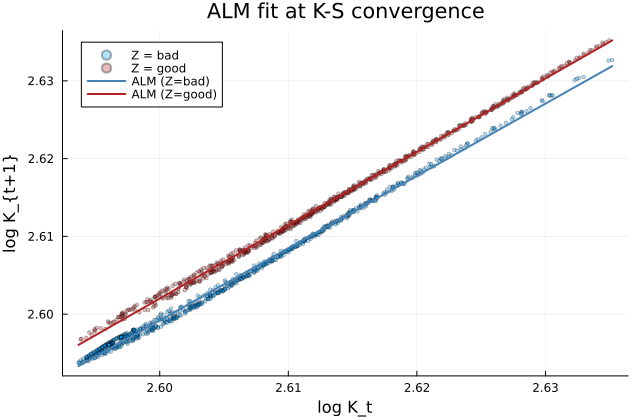

In [15]:
sim = res_ks.sim
mask_bad  = sim.Z_idx_path[window_fit] .== 1
mask_good = sim.Z_idx_path[window_fit] .== 2
x_bad  = log.(sim.K_path[window_fit][mask_bad])
y_bad  = log.(sim.K_path[window_fit .+ 1][mask_bad])
x_good = log.(sim.K_path[window_fit][mask_good])
y_good = log.(sim.K_path[window_fit .+ 1][mask_good])

plt = plot(title="ALM fit at K-S convergence",
           xlabel="log K_t", ylabel="log K_{t+1}", size=(640, 420), legend=:topleft)
scatter!(plt, x_bad,  y_bad;  ms=2, alpha=0.3, label="Z = bad")
scatter!(plt, x_good, y_good; ms=2, alpha=0.3, label="Z = good", color=:firebrick)
x_grid = range(min(minimum(x_bad), minimum(x_good)),
               max(maximum(x_bad), maximum(x_good)); length=50)
plot!(plt, x_grid, res_ks.a0[1] .+ res_ks.a1[1] .* x_grid; lw=2, color=:steelblue, label="ALM (Z=bad)")
plot!(plt, x_grid, res_ks.a0[2] .+ res_ks.a1[2] .* x_grid; lw=2, color=:firebrick, label="ALM (Z=good)")

### 3.7 The Den Haan critique

$R^2$ averages over many periods and can hide systematic bias. Den Haan (2010) proposes a deeper diagnostic: simulate $K$ forward over many periods using *only* the ALM (never using the true law of motion) and compare to the true path.

Den Haan diagnostic: max |%error| over 800 periods = 0.81%


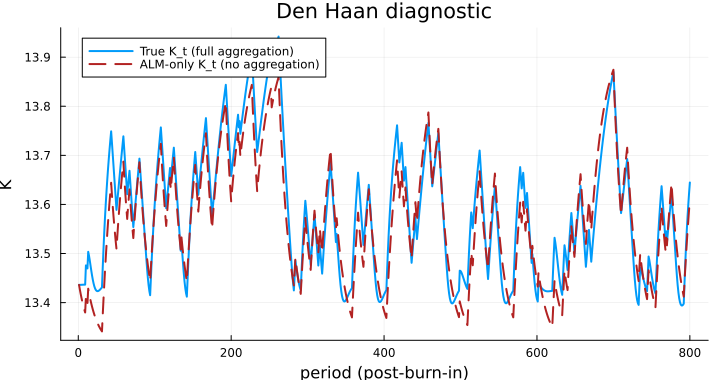

In [16]:
function ks_alm_forward(K_0, Z_idx_path, a0, a1)
    T = length(Z_idx_path)
    K_alm = zeros(T)
    K_alm[1] = K_0
    for t in 1:(T - 1)
        K_alm[t+1] = exp(a0[Z_idx_path[t]] + a1[Z_idx_path[t]] * log(K_alm[t]))
    end
    return K_alm
end

K_alm_path = ks_alm_forward(sim.K_path[T_burn + 1], sim.Z_idx_path[T_burn + 1 : end], res_ks.a0, res_ks.a1)
window_dh = 1:min(800, length(K_alm_path))
true_path = sim.K_path[T_burn + 1 : T_burn + length(K_alm_path)]
max_err_pct = 100 * maximum(abs.(K_alm_path[window_dh] .- true_path[window_dh]) ./ true_path[window_dh])
@printf "Den Haan diagnostic: max |%%error| over %d periods = %.2f%%\n" length(window_dh) max_err_pct

plot(window_dh, true_path[window_dh]; lw=2, label="True K_t (full aggregation)",
     xlabel="period (post-burn-in)", ylabel="K",
     title="Den Haan diagnostic", size=(720, 380))
plot!(window_dh, K_alm_path[window_dh]; lw=2, ls=:dash,
      label="ALM-only K_t (no aggregation)", color=:firebrick)